# Anomaly Detection on Soil Moisture Sensor Data
## Shallot (*Allium cepa var. aggregatum*) Cultivation – ESP32 IoT System

Comparative anomaly detection pipeline

**Methods compared:**
- **Statistical:** Hampel Filter (sliding window + MAD)
- **Machine Learning:** Isolation Forest

**Pipeline stages:**
1. Data Loading & Parsing (Firebase JSON from ESP32)
2. Data Preparation (Missing Value Handling → Z-score Normalization → Time-Series Windowing)
3. Synthetic Anomaly Injection (Spike, Drop, Drift, Stuck)
4. Anomaly Detection (Hampel Filter & Isolation Forest)
5. Performance Evaluation (Precision, Recall, F1-Score, ROC-AUC, PR-AUC)


---
## 0. Library Imports

In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

print("Libraries imported successfully")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : {__import__('sklearn').__version__}")


Libraries imported successfully
  pandas  : 2.2.2
  numpy   : 2.0.2
  sklearn : 1.6.1


---
## 1. Data Loading & Parsing

Load the raw JSON data collected from ESP32 device with 6 soil moisture sensor nodes (Firebase).


In [30]:
JSON_PATH = r"/content/agriculture-esp32 sunday.json"

with open(JSON_PATH, 'r') as f:
    raw_data = json.load(f)

records = []
ag_data = raw_data['agriculture_dataset']

for month_key, month_val in ag_data.items():
    for day_key, day_val in month_val.items():
        for time_key, entry in day_val.items():
            soil = entry.get('soil', {})
            row = {
                'recorded_time': pd.to_datetime(entry['recorded_time']),
                'sensor_1': soil.get('1_Yellow_VP'),
                'sensor_2': soil.get('2_Grey_VN'),
                'sensor_3': soil.get('3_Red_D34'),
                'sensor_4': soil.get('4_Green_D35'),
                'sensor_5': soil.get('5_Black_D32'),
                'sensor_6': soil.get('6_Purple_D33'),
            }
            records.append(row)

df_raw = pd.DataFrame(records)
df_raw.sort_values('recorded_time', inplace=True)
df_raw.reset_index(drop=True, inplace=True)

SENSOR_COLS   = ['sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6']
SENSOR_LABELS = ['1-Yellow(VP)','2-Grey(VN)','3-Red(D34)','4-Green(D35)','5-Black(D32)','6-Purple(D33)']

print(f"Total records loaded : {len(df_raw)}")
print(f"Date range           : {df_raw['recorded_time'].min()} -> {df_raw['recorded_time'].max()}")
print(f"Sensors              : {SENSOR_COLS}")
df_raw.head()


Total records loaded : 4206
Date range           : 2026-06-25 14:21:55 -> 2026-06-28 20:00:41
Sensors              : ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6']


,recorded_time,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6
0,2026-06-25 14:21:55,61,8,64,60,52,68
1,2026-06-25 14:44:14,66,15,67,64,63,70
2,2026-06-25 14:45:14,65,10,66,63,59,67
3,2026-06-25 14:46:14,64,8,65,62,57,67
4,2026-06-25 14:47:14,64,8,66,62,56,67


In [31]:
# Descriptive statistics
print("Descriptive Statistics (Raw Soil Moisture, %)")
df_raw[SENSOR_COLS].describe().round(2)


Descriptive Statistics (Raw Soil Moisture, %)


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6
count,4206.00,4206.00,4206.00,4206.00,4206.00,4206.00
mean,61.80,54.42,62.37,59.57,61.31,64.33
std,1.85,17.09,2.21,4.03,3.74,2.30
min,56.00,0.00,57.00,52.00,47.00,59.00
25%,60.00,57.00,62.00,57.00,61.00,64.00
50%,61.50,61.00,63.00,59.00,63.00,65.00
75%,64.00,64.00,64.00,64.00,64.00,66.00
max,69.00,66.00,70.00,67.00,66.00,72.00


Libraries imported successfully
  pandas  : 2.2.2
  numpy   : 2.0.2
  sklearn : 1.6.1


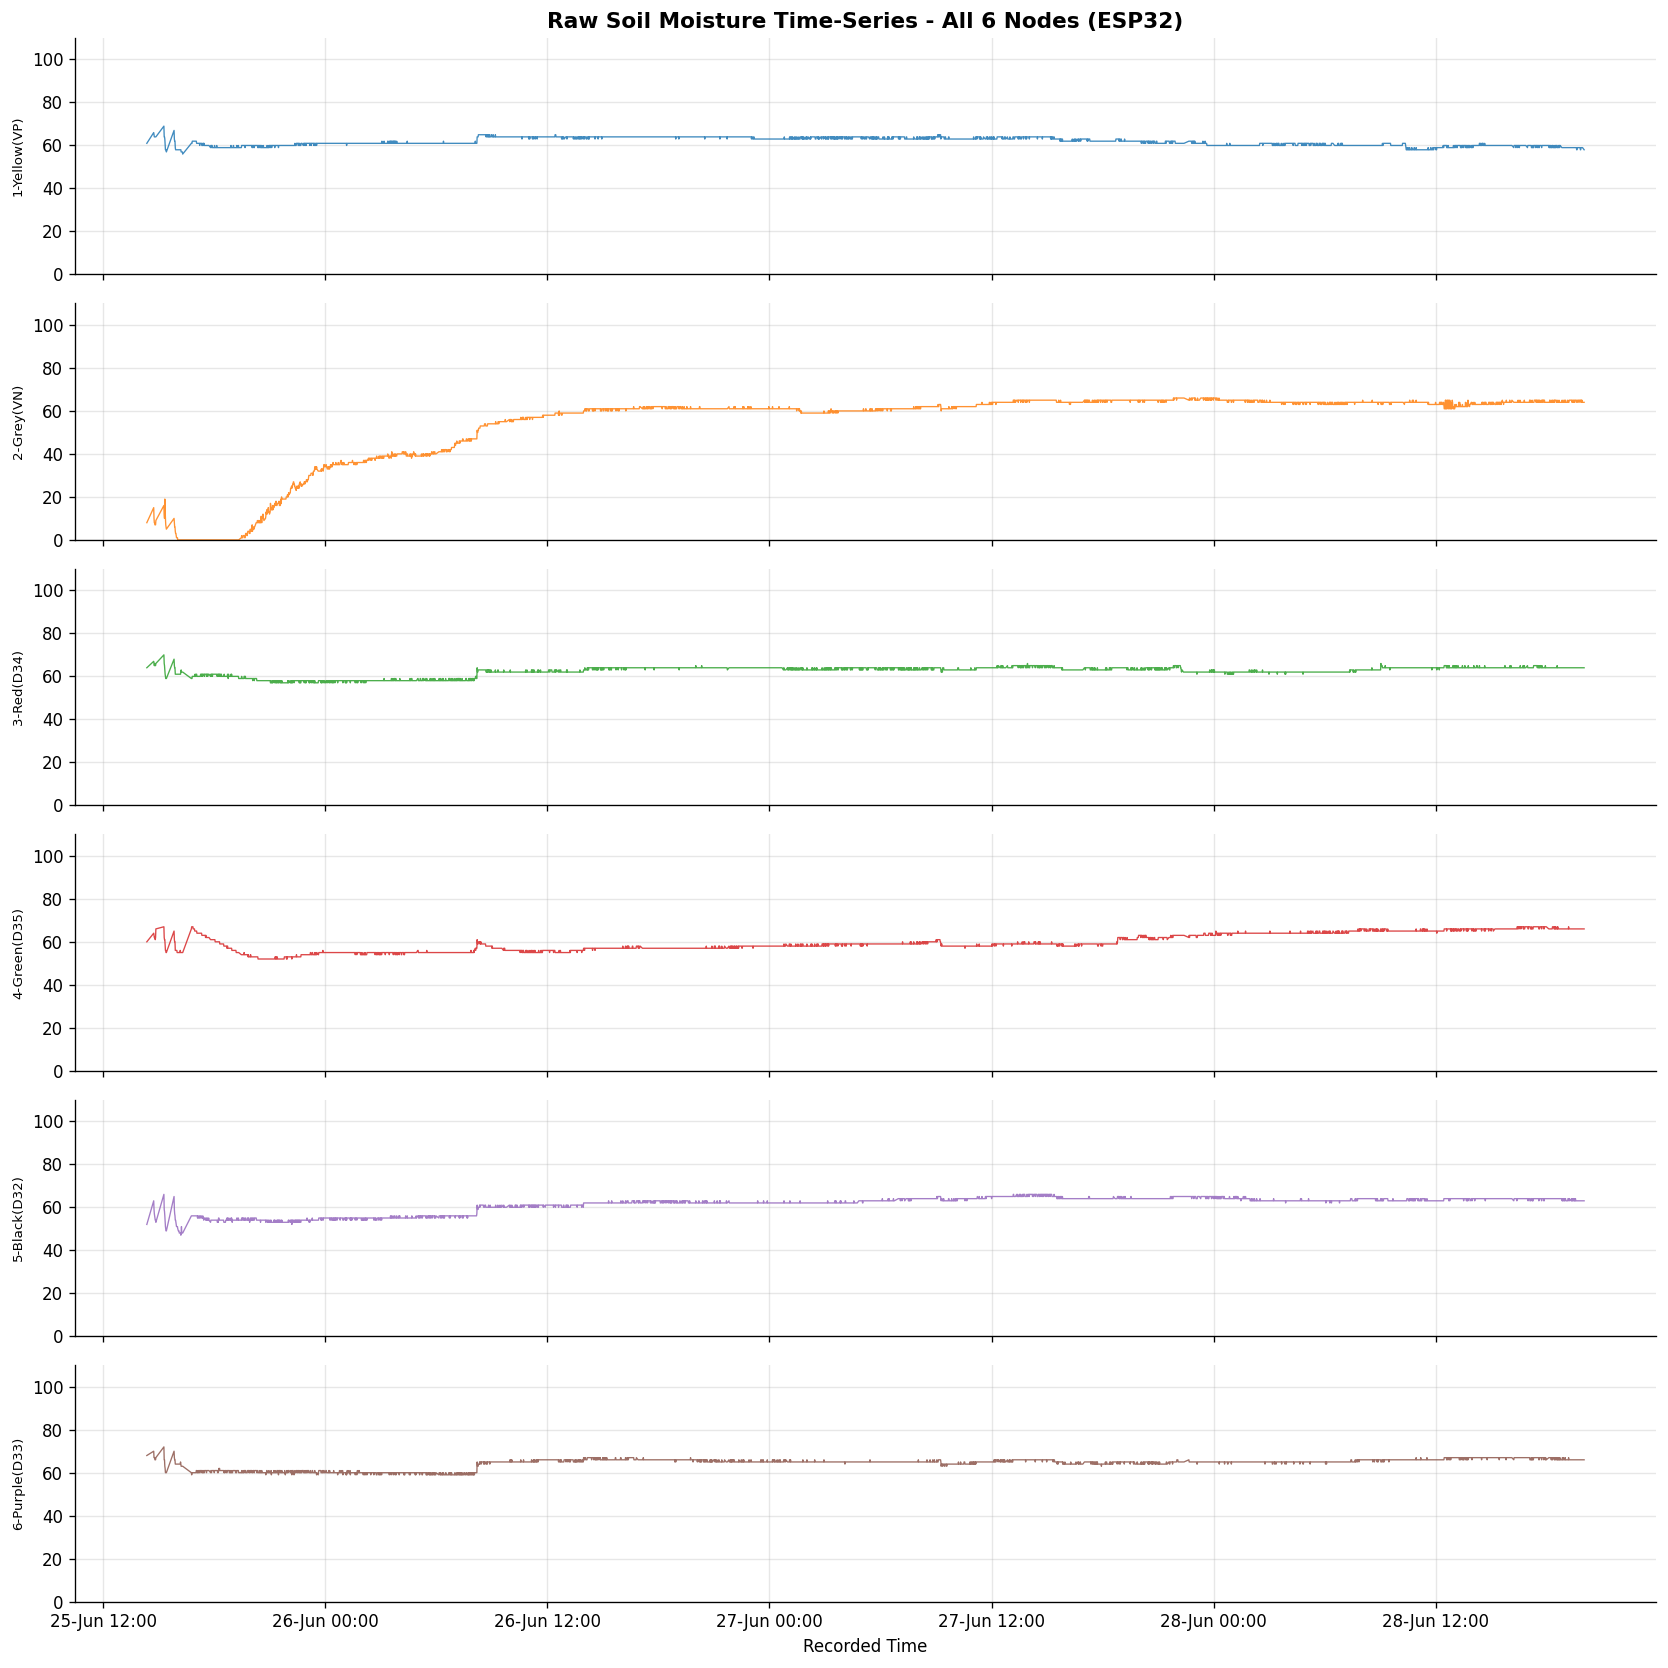

Saved: fig_01_raw_timeseries.png


In [32]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

print("Libraries imported successfully")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : {__import__('sklearn').__version__}")


# Visualize raw time-series for all 6 sensors
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
colors = plt.cm.tab10.colors

for i, (col, label) in enumerate(zip(SENSOR_COLS, SENSOR_LABELS)):
    axes[i].plot(df_raw['recorded_time'], df_raw[col], color=colors[i], linewidth=0.8, alpha=0.85)
    axes[i].set_ylabel(label, fontsize=8)
    axes[i].set_ylim(0, 110)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Raw Soil Moisture Time-Series - All 6 Nodes (ESP32)', fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
axes[-1].set_xlabel('Recorded Time')
fig.tight_layout()
plt.savefig('fig_01_raw_timeseries.png', bbox_inches='tight')
plt.show()
print("Saved: fig_01_raw_timeseries.png")

---
## 2. Data Preparation

Three-step preprocessing pipeline as described in the paper:
1. **Missing Value Handling** – interpolation for communication failure gaps
2. **Z-score Normalization** – align all measurements to a uniform scale
3. **Time-Series Windowing** – consecutive data points into consolidated feature set


### 2.1 Missing Value Handling

In [33]:
df = df_raw.copy()
df.set_index('recorded_time', inplace=True)

print("Missing Values Before Handling:")
print(df[SENSOR_COLS].isnull().sum())

# Resample to 1-minute resolution to expose implicit time gaps
df = df[SENSOR_COLS].resample('1min').mean()
n_gap = df.isnull().sum().sum()
print(f"\nImplicit time gaps after 1-min resampling: {n_gap} values")

# Linear interpolation + forward/backward fill for edge cases
df.interpolate(method='time', inplace=True)
df.ffill(inplace=True)
df.bfill(inplace=True)

print(f"Missing values after interpolation : {df.isnull().sum().sum()}")
print(f"Total time-steps after resampling  : {len(df)}")


Missing Values Before Handling:
sensor_1    0
sensor_2    0
sensor_3    0
sensor_4    0
sensor_5    0
sensor_6    0
dtype: int64

Implicit time gaps after 1-min resampling: 2724 values
Missing values after interpolation : 0
Total time-steps after resampling  : 4660


### 2.2 Z-Score Normalization

In [34]:
df_clean = df.copy()
df_norm  = df_clean.copy()

# Z-score normalization per sensor: z = (x - mu) / sigma
for col in SENSOR_COLS:
    mu    = df_norm[col].mean()
    sigma = df_norm[col].std()
    df_norm[col] = (df_norm[col] - mu) / sigma

print("Z-score Normalization Applied")
print("Normalized Statistics (should be mean~0, std~1):")
df_norm.describe().round(3)


Z-score Normalization Applied
Normalized Statistics (should be mean~0, std~1):


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6
count,4660.000,4660.000,4660.000,4660.000,4660.000,4660.000
mean,0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.069,-2.929,-2.402,-1.886,-3.720,-2.288
25%,-0.959,0.085,-0.180,-0.649,-0.319,-0.160
50%,0.079,0.414,0.264,-0.155,0.466,0.266
75%,1.151,0.578,0.709,1.082,0.727,0.692
max,3.788,0.688,3.374,1.824,1.251,3.246


### 2.3 Time-Series Windowing

In [35]:
WINDOW_SIZE = 10  # 10-minute sliding window

def create_window_features(df_input, sensor_cols, window=10):
    """
    For each time-step t, compute [mean, std, min, max] over
    the previous `window` steps for each sensor column.
    """
    feature_frames = []
    for col in sensor_cols:
        roll = df_input[col].rolling(window=window)
        feat = pd.DataFrame({
            f'{col}_wmean': roll.mean(),
            f'{col}_wstd' : roll.std(),
            f'{col}_wmin' : roll.min(),
            f'{col}_wmax' : roll.max(),
        })
        feature_frames.append(feat)
    combined = pd.concat(feature_frames, axis=1)
    combined.dropna(inplace=True)
    return combined

df_features = create_window_features(df_norm, SENSOR_COLS, window=WINDOW_SIZE)

print(f"Window size   : {WINDOW_SIZE} minutes")
print(f"Feature matrix: {df_features.shape[0]} rows x {df_features.shape[1]} features")
print(f"Features per sensor: mean, std, min, max")
df_features.head(3)


Window size   : 10 minutes
Feature matrix: 4651 rows x 24 features
Features per sensor: mean, std, min, max


,sensor_1_wmean,sensor_1_wstd,sensor_1_wmin,sensor_1_wmax,sensor_2_wmean,sensor_2_wstd,sensor_2_wmin,sensor_2_wmax,sensor_3_wmean,sensor_3_wstd,...,sensor_4_wmin,sensor_4_wmax,sensor_5_wmean,sensor_5_wstd,sensor_5_wmin,sensor_5_wmax,sensor_6_wmean,sensor_6_wstd,sensor_6_wmin,sensor_6_wmax
recorded_time,,,,,,,,,,,,,,,,,,,,,
2026-06-25 14:30:00,0.084410,0.347189,-0.431618,0.600438,-2.415695,0.0505,-2.490753,-2.340638,0.969365,0.175465,...,0.092543,0.479694,-1.848844,0.378798,-2.411852,-1.285837,1.710047,0.11209,1.543448,1.876647
2026-06-25 14:31:00,0.199083,0.347189,-0.316945,0.715111,-2.399016,0.0505,-2.474073,-2.323958,1.027319,0.175465,...,0.135560,0.522711,-1.723731,0.378798,-2.286739,-1.160724,1.747069,0.11209,1.580470,1.913669
2026-06-25 14:32:00,0.313756,0.347189,-0.202272,0.829784,-2.382336,0.0505,-2.457394,-2.307279,1.085273,0.175465,...,0.178576,0.565728,-1.598618,0.378798,-2.161626,-1.035611,1.784091,0.11209,1.617492,1.950691


---
## 3. Synthetic Anomaly Injection

Four anomaly types are injected to create a labeled ground-truth dataset
(as real agricultural sensor systems rarely provide labeled anomaly data).

| Type  | Formula | Description |
|-------|---------|-------------|
| **Spike** | x_hat = x_t + delta  | Sudden positive jump (eq.1) |
| **Drop**  | x_hat = x_t - delta  | Sudden negative drop (eq.2) |
| **Drift** | x_hat = x_t + alpha*(t-t0) | Gradual drift (eq.3) |
| **Stuck** | x_hat = c, t0<=t<=t1 | Sensor frozen at constant (eq.4) |


In [36]:
np.random.seed(42)

# Anomaly parameters
ANOMALY_RATIO  = 0.05   # ~5% of data points are anomalies
SPIKE_DELTA    = 3.5    # delta for spike (normalized units)
DROP_DELTA     = 3.5    # delta for drop
DRIFT_ALPHA    = 0.015  # alpha drift coefficient
STUCK_VALUE    = 0.0    # c for stuck (normalized zero)

DRIFT_LEN = 10 # length of drift window in minutes
STUCK_LEN = 8  # length of stuck window in minutes

# Work on a subset aligned to windowed features index
df_injected = df_norm.loc[df_features.index].copy()
labels      = pd.DataFrame(False, index=df_injected.index, columns=SENSOR_COLS)

n_total = len(df_injected)
points_per = 1 + 1 + DRIFT_LEN + STUCK_LEN  # = 20 (spike, drop, drift_start, stuck_start)
n_anomaly_per_type = max(1, int(n_total * ANOMALY_RATIO / points_per))

def inject_anomalies(series, labels_series, n_per_type,
                     spike_d, drop_d, drift_a, stuck_val, stuck_len):
    """Inject 4 anomaly types into a 1-D sensor series."""
    s   = series.copy()
    lbl = labels_series.copy()
    n   = len(s)

    # Spike: eq.(1)  x_hat_t = x_t + delta
    spike_pos = np.random.choice(n, size=n_per_type, replace=False)
    for p in spike_pos:
        s.iloc[p]  += spike_d
        lbl.iloc[p] = True

    # Drop: eq.(2)  x_hat_t = x_t - delta
    available = list(set(range(n)) - set(spike_pos))
    drop_pos  = np.random.choice(available, size=n_per_type, replace=False)
    for p in drop_pos:
        s.iloc[p]  -= drop_d
        lbl.iloc[p] = True

    # Drift: eq.(3)  x_hat_t = x_t + alpha*(t - t0)
    used  = set(spike_pos) | set(drop_pos)
    free  = list(set(range(n)) - used)
    drift_starts = np.random.choice(free, size=n_per_type, replace=False)
    for t0 in drift_starts:
        end = min(t0 + DRIFT_LEN, n) # Modified here to use DRIFT_LEN
        for dt in range(end - t0):
            s.iloc[t0 + dt]   += drift_a * dt
            lbl.iloc[t0 + dt]  = True

    # Stuck: eq.(4)  x_hat_t = c, t0 <= t <= t1
    all_used = used | set(drift_starts)
    free2    = list(set(range(n)) - all_used)
    stuck_starts = np.random.choice(free2, size=n_per_type, replace=False)
    for t0 in stuck_starts:
        end = min(t0 + stuck_len, n)
        for dt in range(end - t0):
            s.iloc[t0 + dt]   = stuck_val
            lbl.iloc[t0 + dt] = True

    return s, lbl

for col in SENSOR_COLS:
    df_injected[col], labels[col] = inject_anomalies(
        df_injected[col], labels[col], n_anomaly_per_type,
        SPIKE_DELTA, DROP_DELTA, DRIFT_ALPHA, STUCK_VALUE, STUCK_LEN)

y_true = labels.any(axis=1).astype(int)
print(f"Synthetic Anomaly Injection Complete")
print(f"  Total time-steps   : {len(y_true)}")
print(f"  Anomaly time-steps : {y_true.sum()} ({y_true.mean()*100:.1f}%)")
print(f"  Normal  time-steps : {(y_true==0).sum()}")
print()
print("Anomaly count per sensor node:")
print(labels.sum().to_frame(name='Anomaly Count'))

Synthetic Anomaly Injection Complete
  Total time-steps   : 4651
  Anomaly time-steps : 1109 (23.8%)
  Normal  time-steps : 3542

Anomaly count per sensor node:
          Anomaly Count
sensor_1            219
sensor_2            220
sensor_3            219
sensor_4            217
sensor_5            219
sensor_6            219


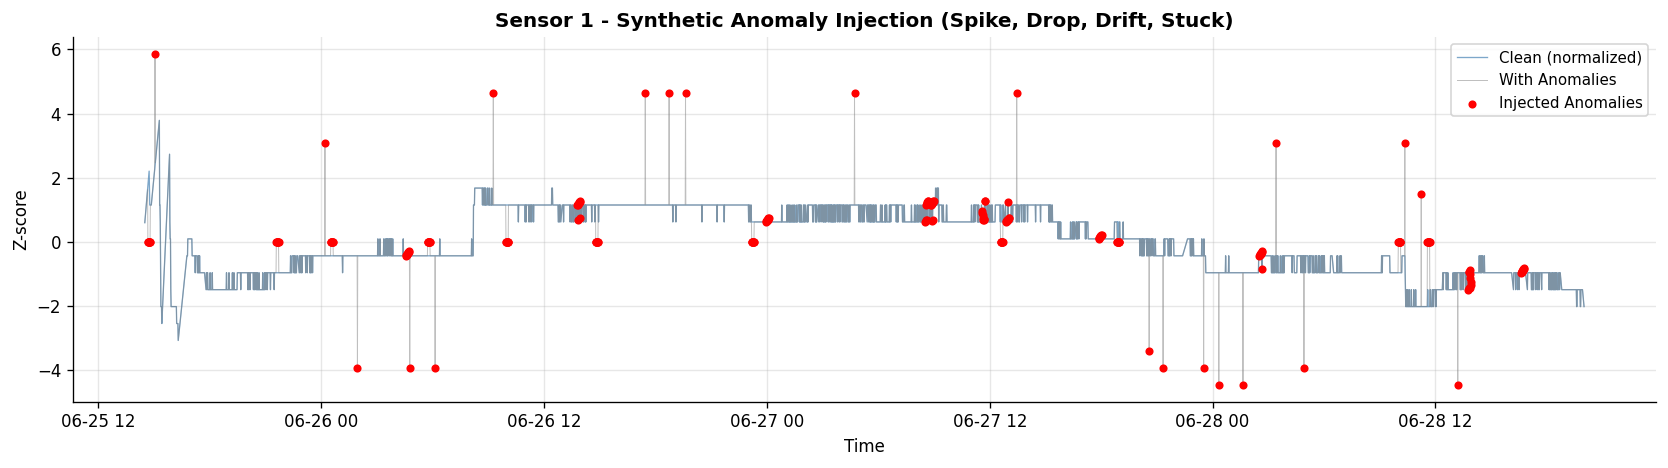

In [37]:
# Visualize injected anomalies for Sensor 1
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_norm.loc[df_features.index, 'sensor_1'],
        color='steelblue', linewidth=0.8, alpha=0.7, label='Clean (normalized)')
ax.plot(df_injected['sensor_1'],
        color='gray', linewidth=0.6, alpha=0.5, label='With Anomalies')

anom_idx = labels.index[labels['sensor_1']]
ax.scatter(anom_idx, df_injected.loc[anom_idx, 'sensor_1'],
           color='red', s=15, zorder=5, label='Injected Anomalies')

ax.set_title('Sensor 1 - Synthetic Anomaly Injection (Spike, Drop, Drift, Stuck)', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Z-score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('fig_02_anomaly_injection.png', bbox_inches='tight')
plt.show()


Visualizing the new anomaly distribution after the fix.

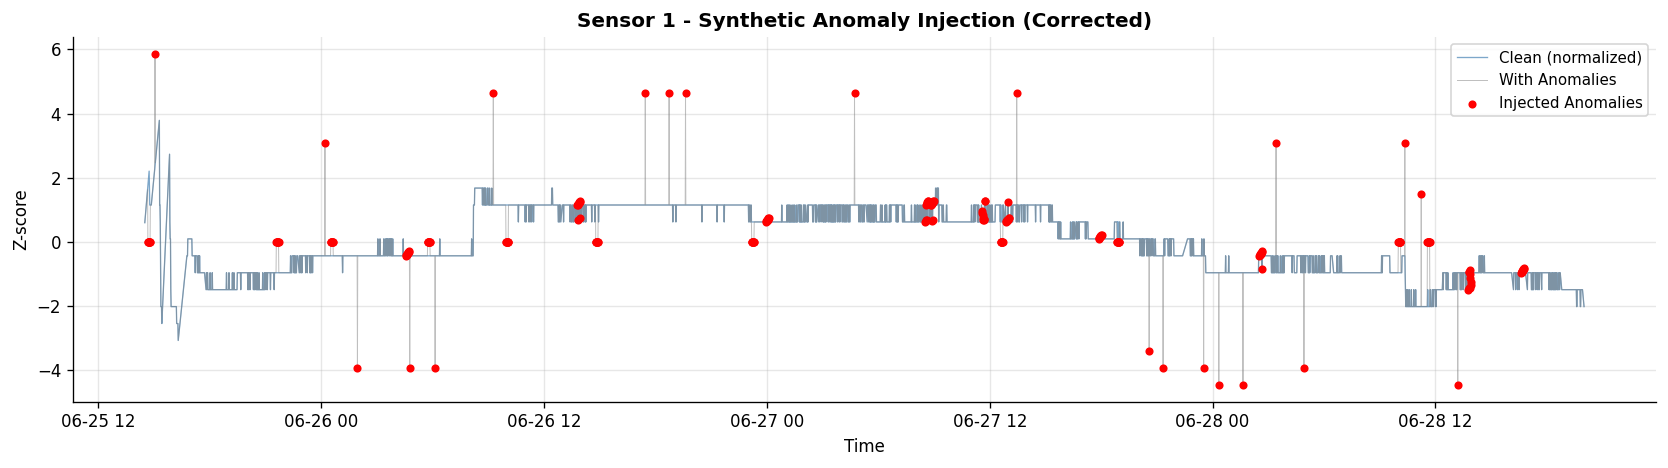

Saved: fig_02_anomaly_injection_corrected.png


In [38]:
# Visualize injected anomalies for Sensor 1 with corrected parameters
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_norm.loc[df_features.index, 'sensor_1'],
        color='steelblue', linewidth=0.8, alpha=0.7, label='Clean (normalized)')
ax.plot(df_injected['sensor_1'],
        color='gray', linewidth=0.6, alpha=0.5, label='With Anomalies')

anom_idx = labels.index[labels['sensor_1']]
ax.scatter(anom_idx, df_injected.loc[anom_idx, 'sensor_1'],
           color='red', s=15, zorder=5, label='Injected Anomalies')

ax.set_title('Sensor 1 - Synthetic Anomaly Injection (Corrected)', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Z-score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('fig_02_anomaly_injection_corrected.png', bbox_inches='tight')
plt.show()
print("Saved: fig_02_anomaly_injection_corrected.png")

---
## 4. Anomaly Detection

### 4.1 Statistical Method: Hampel Filter

Equations from the paper:

- H_t = |x_t - m| / (1.4826 * MAD)  ... (5)
- MAD = median(|x_t - m|)            ... (6)
- Flag anomaly when H_t > k, k=3     ... (7)

Each sensor is treated **independently** (soil moisture is heterogeneous
due to uneven irrigation, root uptake, and media porosity).


In [39]:
def hampel_filter(series, window_size=10, k=3):
    """
    Hampel Filter for 1-D time-series anomaly detection.
    H_t = |x_t - m| / (1.4826 * MAD)    [eq.5]
    MAD = median(|x_t - m|)              [eq.6]
    Flag as anomaly if H_t > k (k=3)     [eq.7]
    """
    n      = len(series)
    flags  = pd.Series(False, index=series.index)
    scores = pd.Series(0.0,   index=series.index)

    for t in range(n):
        lo = max(0, t - window_size)
        hi = min(n, t + window_size + 1)
        window_vals = series.iloc[lo:hi].values
        m   = np.median(window_vals)                         # sliding window median
        mad = np.median(np.abs(window_vals - m))             # MAD eq.(6)
        H_t = 0.0 if mad == 0 else np.abs(series.iloc[t] - m) / (1.4826 * mad)  # eq.(5)
        scores.iloc[t] = H_t
        if H_t > k:                                          # eq.(7) k=3
            flags.iloc[t] = True

    return flags, scores

HAMPEL_WINDOW = 10
HAMPEL_K      = 3

hampel_flags_per_sensor  = {}
hampel_scores_per_sensor = {}

print("Running Hampel Filter on all 6 sensors...")
for col in SENSOR_COLS:
    fl, sc = hampel_filter(df_injected[col], window_size=HAMPEL_WINDOW, k=HAMPEL_K)
    hampel_flags_per_sensor[col]  = fl
    hampel_scores_per_sensor[col] = sc
    print(f"  {col}: {fl.sum()} anomalies detected")

hampel_df   = pd.DataFrame(hampel_flags_per_sensor)
y_pred_hamp = hampel_df.any(axis=1).astype(int)
scores_hamp_df = pd.DataFrame(hampel_scores_per_sensor)
scores_hamp    = scores_hamp_df.max(axis=1)

print(f"\nHampel Filter Complete (window={HAMPEL_WINDOW}, k={HAMPEL_K})")
print(f"Total detected anomalies: {y_pred_hamp.sum()}")


Running Hampel Filter on all 6 sensors...
  sensor_1: 40 anomalies detected
  sensor_2: 58 anomalies detected
  sensor_3: 27 anomalies detected
  sensor_4: 37 anomalies detected
  sensor_5: 38 anomalies detected
  sensor_6: 26 anomalies detected

Hampel Filter Complete (window=10, k=3)
Total detected anomalies: 224


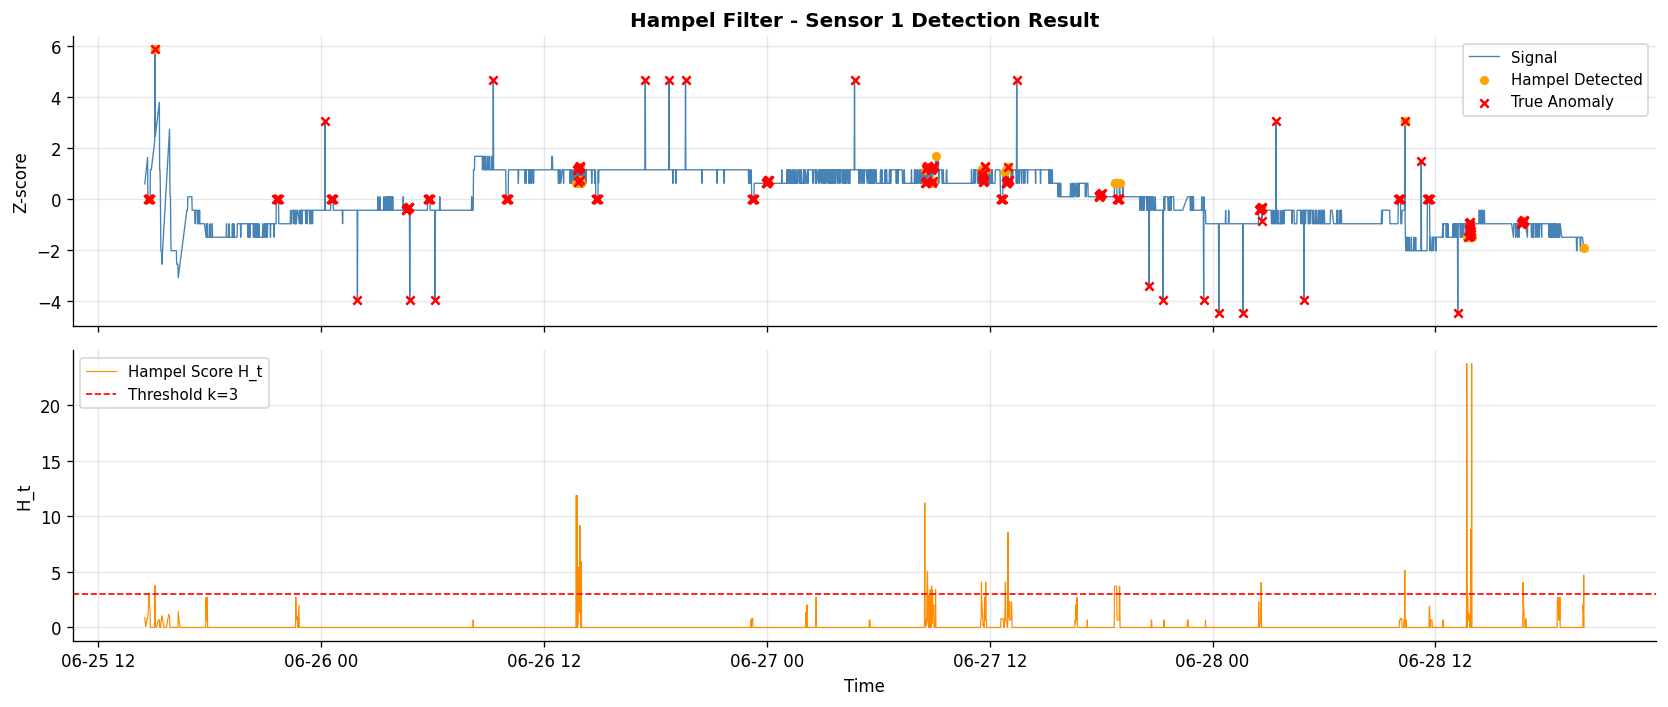

In [40]:
# Visualize Hampel detection on Sensor 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
col = 'sensor_1'

ax1.plot(df_injected.index, df_injected[col], color='steelblue', linewidth=0.8, label='Signal')
det_idx  = hampel_flags_per_sensor[col][hampel_flags_per_sensor[col]].index
ax1.scatter(det_idx, df_injected.loc[det_idx, col], color='orange', s=20, zorder=5, label='Hampel Detected')
true_idx = labels.index[labels[col]]
ax1.scatter(true_idx, df_injected.loc[true_idx, col], color='red', marker='x', s=25, zorder=6, label='True Anomaly')
ax1.set_ylabel('Z-score'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_title('Hampel Filter - Sensor 1 Detection Result', fontweight='bold')

ax2.plot(hampel_scores_per_sensor[col], color='darkorange', linewidth=0.7, label='Hampel Score H_t')
ax2.axhline(HAMPEL_K, color='red', linestyle='--', linewidth=1, label=f'Threshold k={HAMPEL_K}')
ax2.set_ylabel('H_t'); ax2.set_xlabel('Time'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig('fig_03_hampel_result.png', bbox_inches='tight')
plt.show()


### 4.2 Machine Learning Method: Isolation Forest

Anomaly score formula from the paper:

s(x, n) = 2 - E[h(x)] / c(n)    ... (8)

Where:
- E[h(x)] = average path length to isolate observation x
- n = total number of samples
- c(n) = normalization factor (expected path length)
- Higher score → more likely anomaly

Isolation Forest does **not** assume data distribution and detects
complex patterns without supervision.


In [41]:
# Build windowed features on the INJECTED data
df_features_injected = create_window_features(df_injected, SENSOR_COLS, window=WINDOW_SIZE)
y_true_if = y_true.loc[df_features_injected.index]

contamination_rate = float(y_true_if.mean())
print(f"Contamination rate (ground truth): {contamination_rate:.4f}")

# IsolationForest's 'contamination' parameter must be between 0.0 and 0.5.
# We cap it at 0.5 to satisfy this constraint, even if actual is higher.
if contamination_rate > 0.5:
    contamination_rate_for_if = 0.5
else:
    contamination_rate_for_if = contamination_rate

IF_MODEL = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate_for_if,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

X = df_features_injected.values
IF_MODEL.fit(X)

# +1 = normal, -1 = anomaly  ->  remap to 0/1
raw_pred  = IF_MODEL.predict(X)
y_pred_if = pd.Series((raw_pred == -1).astype(int), index=df_features_injected.index)

# Anomaly score: higher = more anomalous (negate decision function)
scores_if = pd.Series(-IF_MODEL.decision_function(X), index=df_features_injected.index)

print(f"Isolation Forest Complete")
print(f"  n_estimators       : 200")
print(f"  contamination      : {contamination_rate_for_if:.4f} (capped)")
print(f"  Detected anomalies : {y_pred_if.sum()}")

Contamination rate (ground truth): 0.2389
Isolation Forest Complete
  n_estimators       : 200
  contamination      : 0.2389 (capped)
  Detected anomalies : 1109


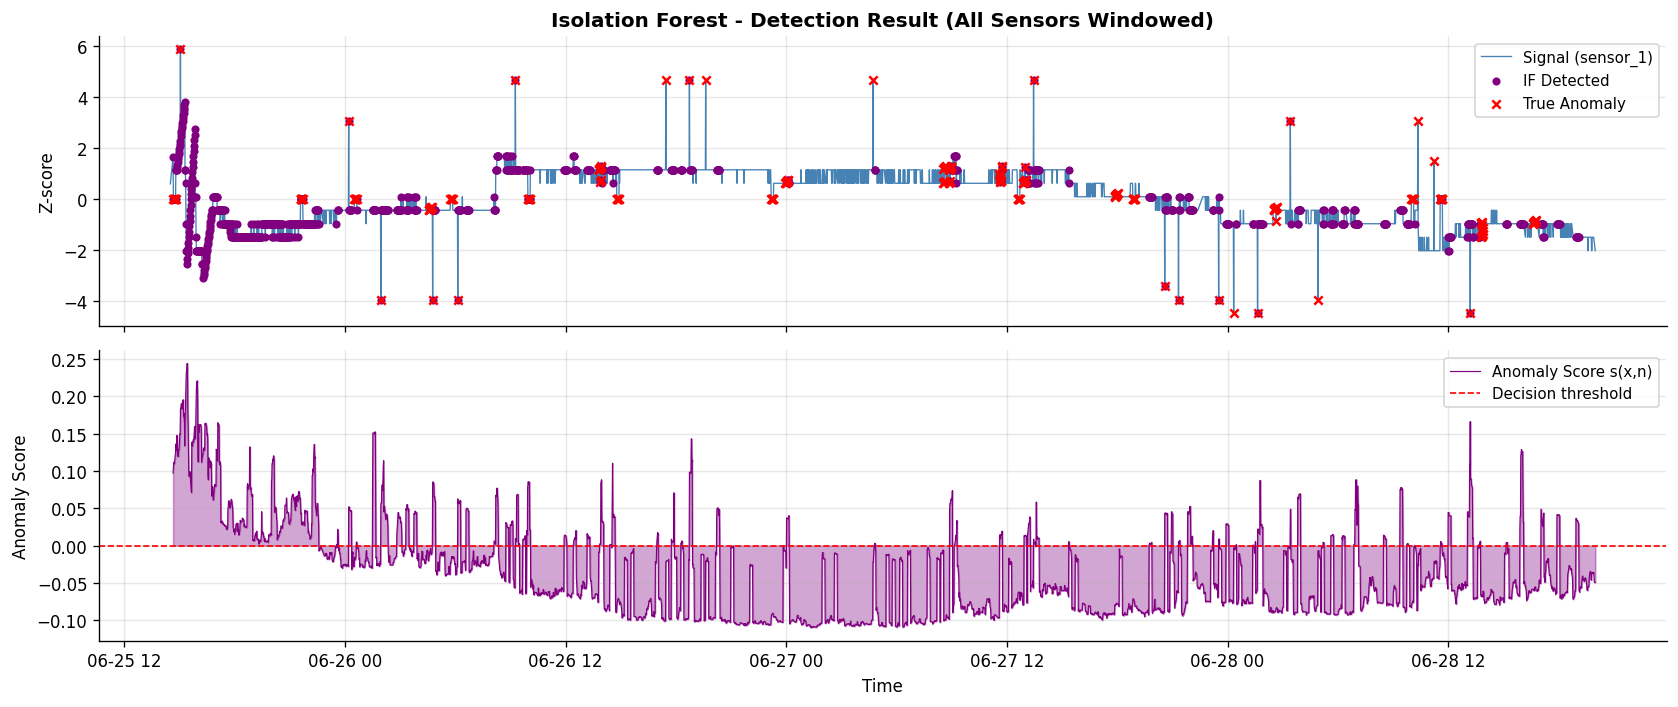

In [42]:
# Visualize IF anomaly scores
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df_injected.index, df_injected['sensor_1'], color='steelblue', linewidth=0.8, label='Signal (sensor_1)')
if_anom_idx = y_pred_if[y_pred_if == 1].index
ax1.scatter(if_anom_idx, df_injected.loc[if_anom_idx, 'sensor_1'],
            color='purple', s=15, zorder=5, label='IF Detected')
true_idx = labels.index[labels['sensor_1']]
ax1.scatter(true_idx, df_injected.loc[true_idx, 'sensor_1'],
            color='red', marker='x', s=25, zorder=6, label='True Anomaly')
ax1.set_ylabel('Z-score'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_title('Isolation Forest - Detection Result (All Sensors Windowed)', fontweight='bold')

ax2.fill_between(scores_if.index, scores_if, alpha=0.35, color='purple')
ax2.plot(scores_if, color='purple', linewidth=0.7, label='Anomaly Score s(x,n)')
ax2.axhline(scores_if.quantile(1 - contamination_rate), color='red',
            linestyle='--', linewidth=1, label='Decision threshold')
ax2.set_ylabel('Anomaly Score'); ax2.set_xlabel('Time')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('fig_04_iforest_result.png', bbox_inches='tight')
plt.show()


---
## 5. Performance Evaluation

Five metrics evaluated from the confusion matrix (TP, TN, FP, FN):

| Metric | Formula |
|--------|---------|
| **Precision** | TP / (TP + FP) |
| **Recall**    | TP / (TP + FN) |
| **F1-Score**  | 2 * (Precision * Recall) / (Precision + Recall) |
| **ROC-AUC**   | Area under Receiver Operating Characteristic curve |
| **PR-AUC**    | Area under Precision-Recall curve (useful for imbalanced datasets) |


In [43]:
# Align indices to common evaluation set
common_idx   = df_features_injected.index

y_true_eval  = y_true.loc[common_idx]
y_pred_hamp_ = y_pred_hamp.loc[common_idx]
scores_hamp_ = scores_hamp.loc[common_idx]
y_pred_if_   = y_pred_if.loc[common_idx]
scores_if_   = scores_if.loc[common_idx]

def evaluate(y_true_e, y_pred, y_score, name):
    return {
        'Method'   : name,
        'Precision': round(precision_score(y_true_e, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true_e, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true_e, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true_e, y_score), 4),
        'PR-AUC'   : round(average_precision_score(y_true_e, y_score), 4),
    }

results = [
    evaluate(y_true_eval, y_pred_hamp_, scores_hamp_, 'Hampel Filter'),
    evaluate(y_true_eval, y_pred_if_,   scores_if_,   'Isolation Forest'),
]
df_results = pd.DataFrame(results).set_index('Method')

print("PERFORMANCE EVALUATION RESULTS")
print("=" * 60)
print(df_results.to_string())
print("=" * 60)


PERFORMANCE EVALUATION RESULTS
                  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Method                                                        
Hampel Filter        0.7812  0.1578    0.2626   0.7043  0.4728
Isolation Forest     0.3282  0.3282    0.3282   0.5997  0.3161


### 5.1 Confusion Matrices

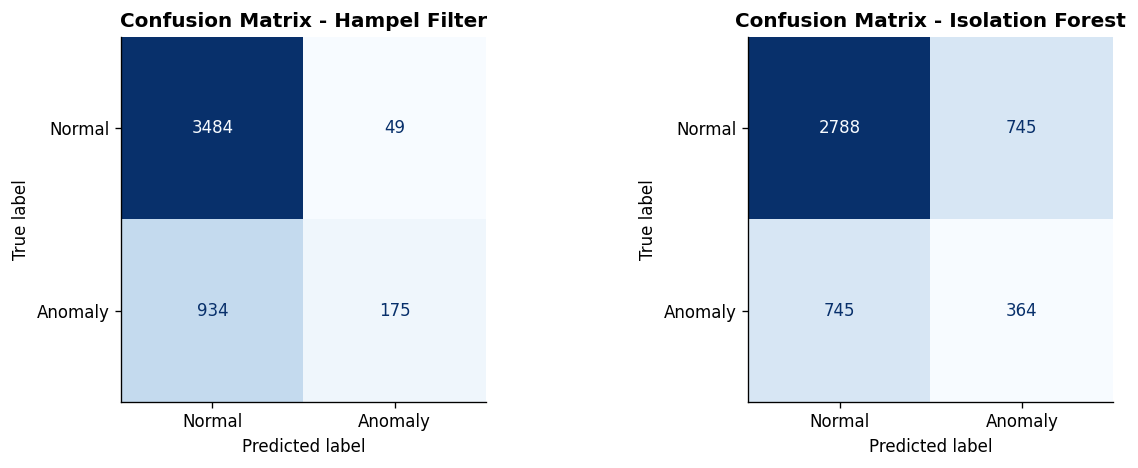

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_pred, title) in zip(axes,
        [(y_pred_hamp_, 'Hampel Filter'), (y_pred_if_, 'Isolation Forest')]):
    cm   = confusion_matrix(y_true_eval, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {title}', fontweight='bold')
fig.tight_layout()
plt.savefig('fig_05_confusion_matrices.png', bbox_inches='tight')
plt.show()


### 5.2 ROC-AUC Curves

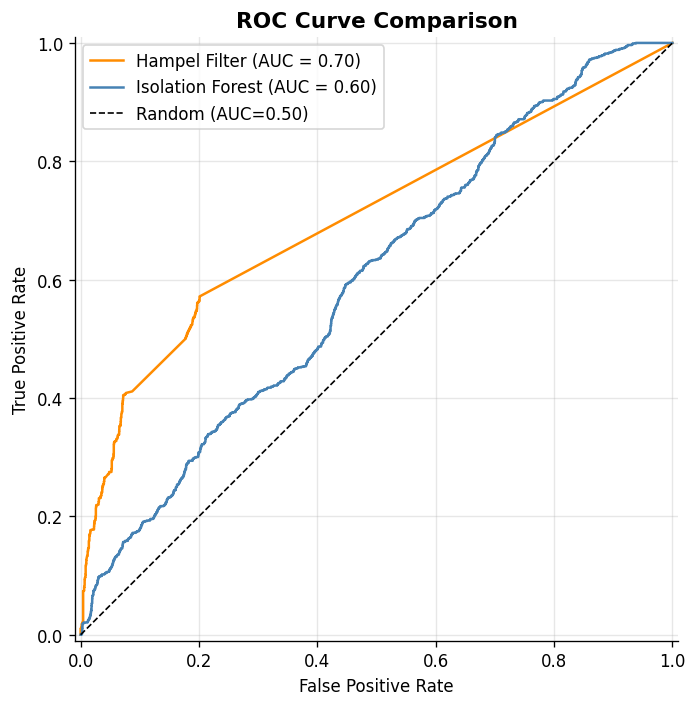

In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_true_eval, scores_hamp_, name='Hampel Filter',    ax=ax, color='darkorange')
RocCurveDisplay.from_predictions(y_true_eval, scores_if_,   name='Isolation Forest', ax=ax, color='steelblue')
ax.plot([0,1],[0,1],'k--',linewidth=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('fig_06_roc_curves.png', bbox_inches='tight')
plt.show()


### 5.3 Precision-Recall Curves

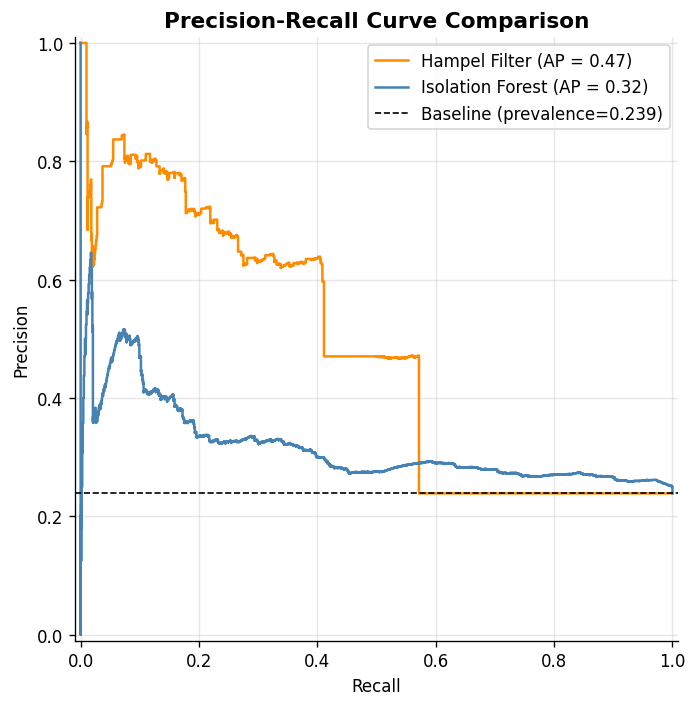

In [46]:
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_true_eval, scores_hamp_, name='Hampel Filter',    ax=ax, color='darkorange')
PrecisionRecallDisplay.from_predictions(y_true_eval, scores_if_,   name='Isolation Forest', ax=ax, color='steelblue')
baseline = y_true_eval.mean()
ax.axhline(baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline (prevalence={baseline:.3f})')
ax.set_title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('fig_07_pr_curves.png', bbox_inches='tight')
plt.show()


### 5.4 Metric Comparison Bar Chart

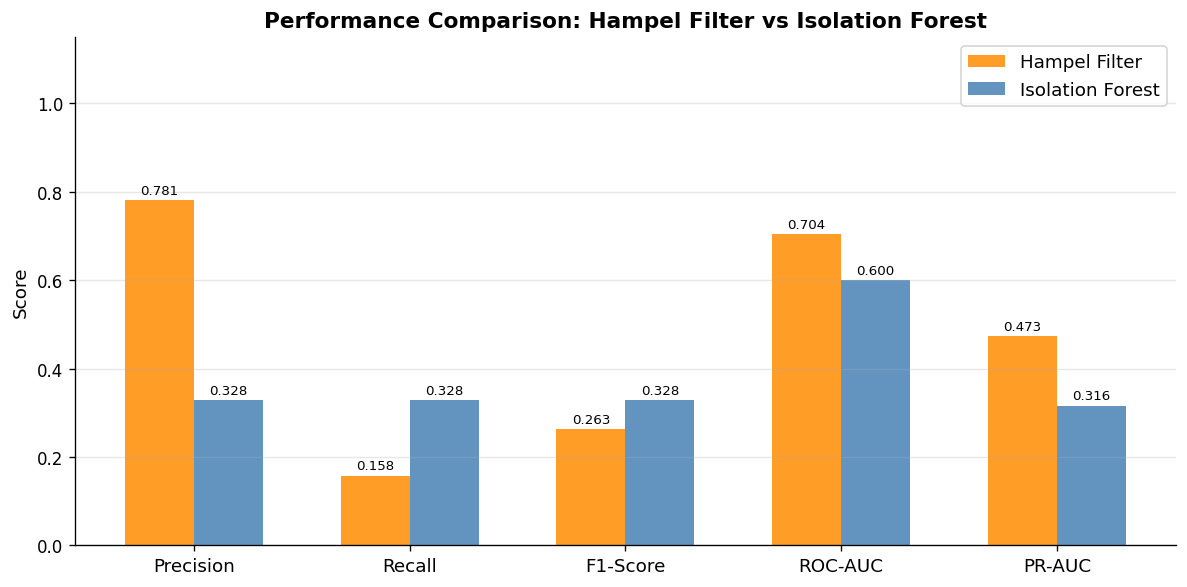

In [47]:
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
x = np.arange(len(metrics))
w = 0.32
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, df_results.loc['Hampel Filter',    metrics], w, label='Hampel Filter',    color='darkorange', alpha=0.85)
b2 = ax.bar(x + w/2, df_results.loc['Isolation Forest', metrics], w, label='Isolation Forest', color='steelblue',  alpha=0.85)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Comparison: Hampel Filter vs Isolation Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig('fig_08_metric_comparison.png', bbox_inches='tight')
plt.show()


---
## 6. Per-Sensor Detection Detail

In [48]:
per_sensor_results = []
for col, label_name in zip(SENSOR_COLS, SENSOR_LABELS):
    y_t  = labels[col].astype(int).loc[common_idx]
    y_h  = hampel_flags_per_sensor[col].astype(int).loc[common_idx]
    f1_h = f1_score(y_t, y_h,             zero_division=0)
    f1_i = f1_score(y_t, y_pred_if_.loc[common_idx], zero_division=0)
    per_sensor_results.append({
        'Sensor'   : label_name,
        'Hampel F1': round(f1_h, 4),
        'IF F1'    : round(f1_i, 4),
        'Anomalies': int(y_t.sum())
    })
df_per_sensor = pd.DataFrame(per_sensor_results).set_index('Sensor')
print("Per-Sensor F1-Score Breakdown:")
print(df_per_sensor.to_string())


Per-Sensor F1-Score Breakdown:
               Hampel F1   IF F1  Anomalies
Sensor                                     
1-Yellow(VP)      0.1158  0.1205        219
2-Grey(VN)        0.3885  0.1264        220
3-Red(D34)        0.1138  0.1340        219
4-Green(D35)      0.2598  0.0769        217
5-Black(D32)      0.2179  0.1039        219
6-Purple(D33)     0.1388  0.1009        219


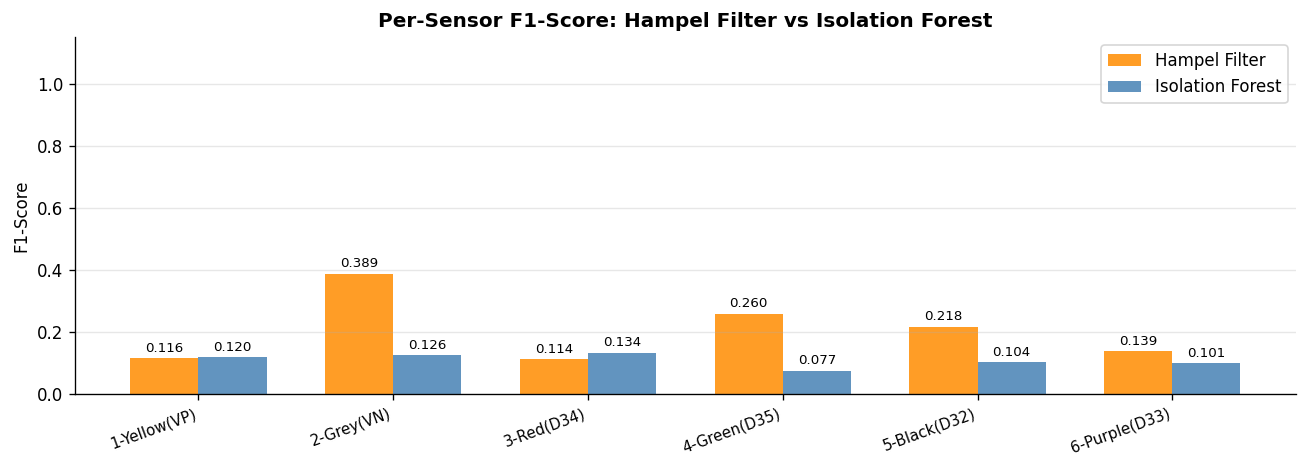

In [49]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(SENSOR_LABELS)); w = 0.35
b1 = ax.bar(x - w/2, df_per_sensor['Hampel F1'], w, label='Hampel Filter',    color='darkorange', alpha=0.85)
b2 = ax.bar(x + w/2, df_per_sensor['IF F1'],     w, label='Isolation Forest', color='steelblue',  alpha=0.85)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(SENSOR_LABELS, fontsize=9, rotation=20, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('F1-Score')
ax.set_title('Per-Sensor F1-Score: Hampel Filter vs Isolation Forest', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig('fig_09_per_sensor_f1.png', bbox_inches='tight')
plt.show()


---
## 7. Additional Exploratory Data Analysis

### 7.1 Temporal Analysis: Hourly Average Soil Moisture
This heatmap visualizes the average soil moisture values for each sensor, grouped by hour of the day. This helps identify daily patterns and specific hours where soil moisture tends to fluctuate or remain stable, which can be indicative of environmental factors or irrigation schedules.

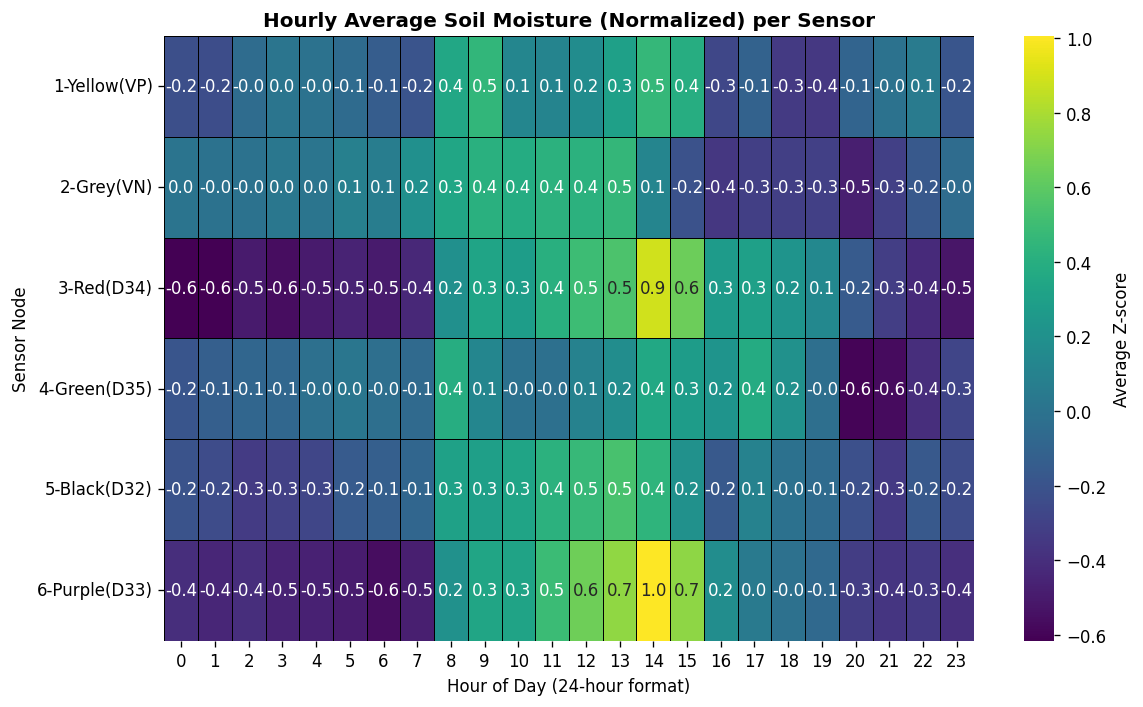

In [52]:
# Calculate hourly average for df_injected (normalized data with anomalies)
df_hourly_avg = df_injected.groupby(df_injected.index.hour).mean()
df_hourly_avg.index.name = 'Hour of Day'

# Map sensor columns to more descriptive labels for the plot
df_hourly_avg.columns = SENSOR_LABELS

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df_hourly_avg.T,  # Transpose to have sensors on Y-axis and hours on X-axis
    cmap='viridis',   # Professional colormap
    annot=True,
    fmt=".1f",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Average Z-score'}
)
ax.set_title('Hourly Average Soil Moisture (Normalized) per Sensor', fontweight='bold')
ax.set_xlabel('Hour of Day (24-hour format)')
ax.set_ylabel('Sensor Node')
fig.tight_layout()
plt.savefig('fig_10_hourly_heatmap.png', bbox_inches='tight')
plt.show()

### 7.2 Spatial Correlation: Sensor Correlation Matrix
This heatmap displays the Pearson correlation coefficients between all pairs of the 6 soil moisture sensors. A high positive correlation (close to 1) indicates that sensors tend to move in the same direction, while a low or negative correlation suggests independent or inverse behavior. This can reveal insights into sensor placement, soil homogeneity, or localized effects.

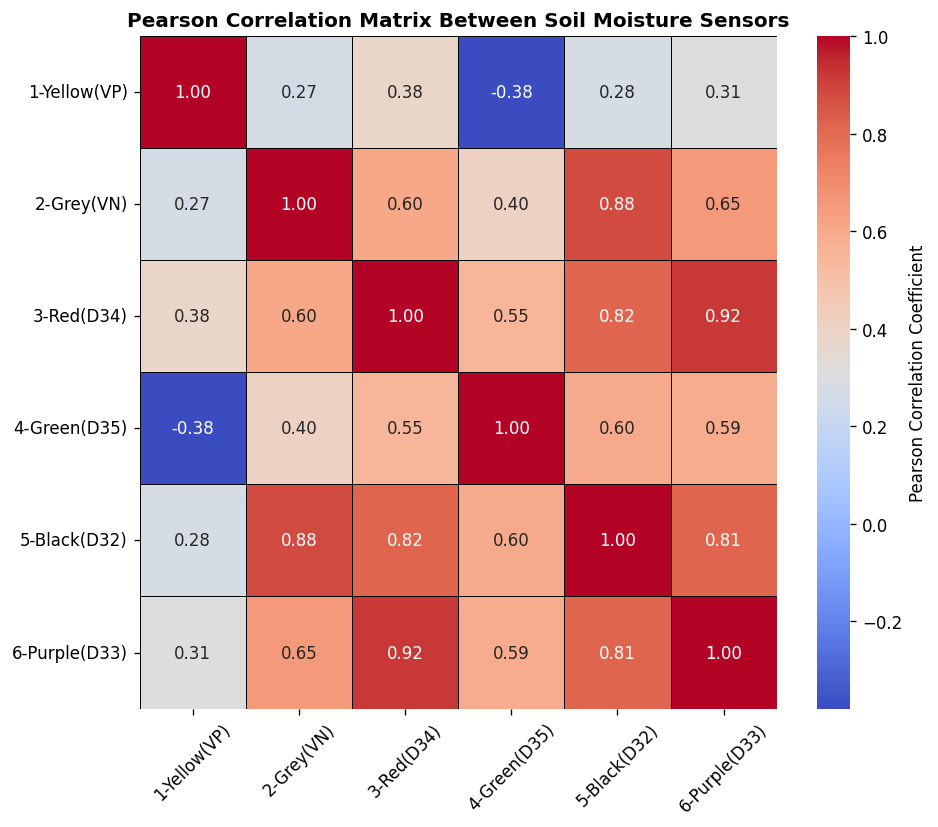

In [56]:
# Calculate the Pearson correlation matrix for the cleaned (interpolated) data
correlation_matrix = df_clean[SENSOR_COLS].corr()

# Rename columns and index for better readability in the plot
correlation_matrix.columns = SENSOR_LABELS
correlation_matrix.index = SENSOR_LABELS

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm', # Colormap for correlations, showing positive/negative clearly
    fmt=".2f",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
ax.set_title('Pearson Correlation Matrix Between Soil Moisture Sensors', fontweight='bold')
ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for better fit
ax.tick_params(axis='y', rotation=0)
fig.tight_layout()
plt.savefig('fig_11_correlation_matrix.png', bbox_inches='tight')
plt.show()

### 7.3 Communication Failure Analysis: Missing Data Map
This visualization identifies periods when the ESP32 failed to transmit data, resulting in missing values. By resampling the raw data to a 1-minute interval and explicitly showing `NaN`s, we can pinpoint when and for how long communication gaps occurred. This is crucial for understanding data reliability and the impact of communication issues on subsequent analysis.

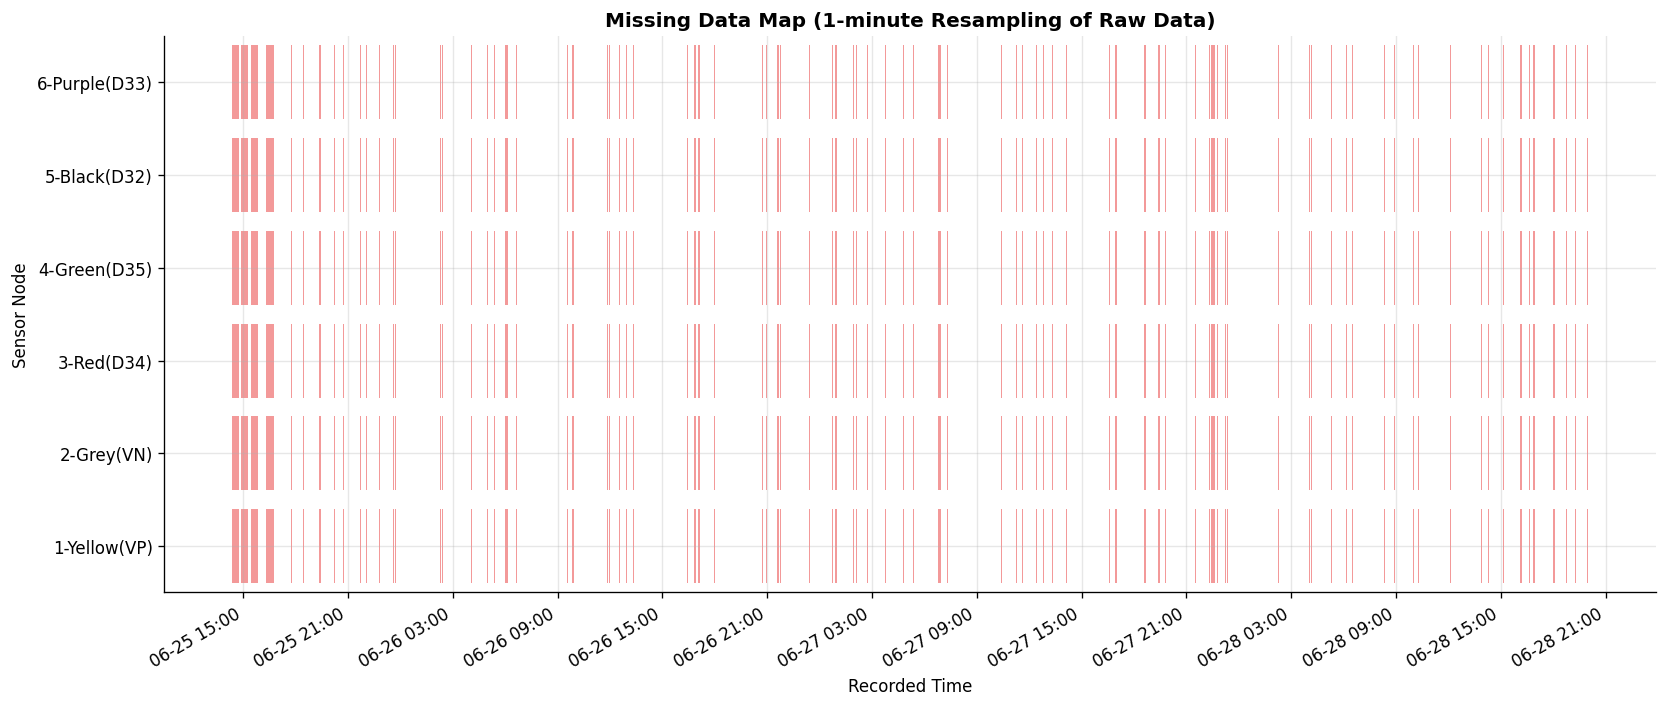

In [57]:
# Create a temporary DataFrame by resampling df_raw to 1-minute and keeping NaNs
df_missing = df_raw.set_index('recorded_time')[SENSOR_COLS].resample('1min').mean()

# Create a boolean DataFrame indicating where values are NaN
missing_mask = df_missing.isna()

# Map sensor columns to more descriptive labels for the plot
missing_mask.columns = SENSOR_LABELS

# Prepare data for plotting (only show True values, i.e., missing data)
# We will use a scatter plot or a similar representation for clarity over a heatmap for individual points.

# Since matplotlib's `broken_barh` is good for visualizing intervals, let's prepare data for it.
# Iterate through each sensor and find blocks of missing data.
plot_data = []
for i, col in enumerate(SENSOR_LABELS):
    missing_intervals = []
    in_missing_block = False
    start_time = None

    for idx, is_missing in missing_mask[col].items():
        if is_missing and not in_missing_block:
            start_time = mdates.date2num(idx)
            in_missing_block = True
        elif not is_missing and in_missing_block:
            end_time = mdates.date2num(idx)
            missing_intervals.append((start_time, end_time - start_time))
            in_missing_block = False
    # Handle case where missing block extends to the end of the series
    if in_missing_block:
        end_time = mdates.date2num(missing_mask.index[-1])
        missing_intervals.append((start_time, end_time - start_time))
    if missing_intervals:
        plot_data.append((i, missing_intervals))

fig, ax = plt.subplots(figsize=(14, 6))

# Use a single color for all missing data to represent absence of data
missing_color = 'lightcoral'

if not plot_data:
    ax.text(0.5, 0.5, 'No missing data found after resampling', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12)
else:
    for sensor_idx, intervals in plot_data:
        ax.broken_barh(intervals, (sensor_idx - 0.4, 0.8), facecolors=missing_color, alpha=0.8)

ax.set_yticks(range(len(SENSOR_LABELS)))
ax.set_yticklabels(SENSOR_LABELS)
ax.set_ylim(-0.5, len(SENSOR_LABELS) - 0.5)

# Format x-axis as dates/times
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.set_xlabel('Recorded Time')
ax.set_ylabel('Sensor Node')
ax.set_title('Missing Data Map (1-minute Resampling of Raw Data)', fontweight='bold')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate() # Auto-format date labels for better readability
fig.tight_layout()
plt.savefig('fig_12_missing_data_map.png', bbox_inches='tight')
plt.show()


### 7.4 Detection Accuracy vs. Anomaly Duration
This analysis evaluates the True Positive (TP) ratio of both Hampel Filter and Isolation Forest, distinguishing between single-step anomalies (duration = 1 time-step) and multi-step anomalies (duration $\ge 3$ time-steps). This comparison highlights how each method performs on different types of anomalies, which is crucial given the synthetic injection of both short (spike/drop) and longer (drift/stuck) anomalies.

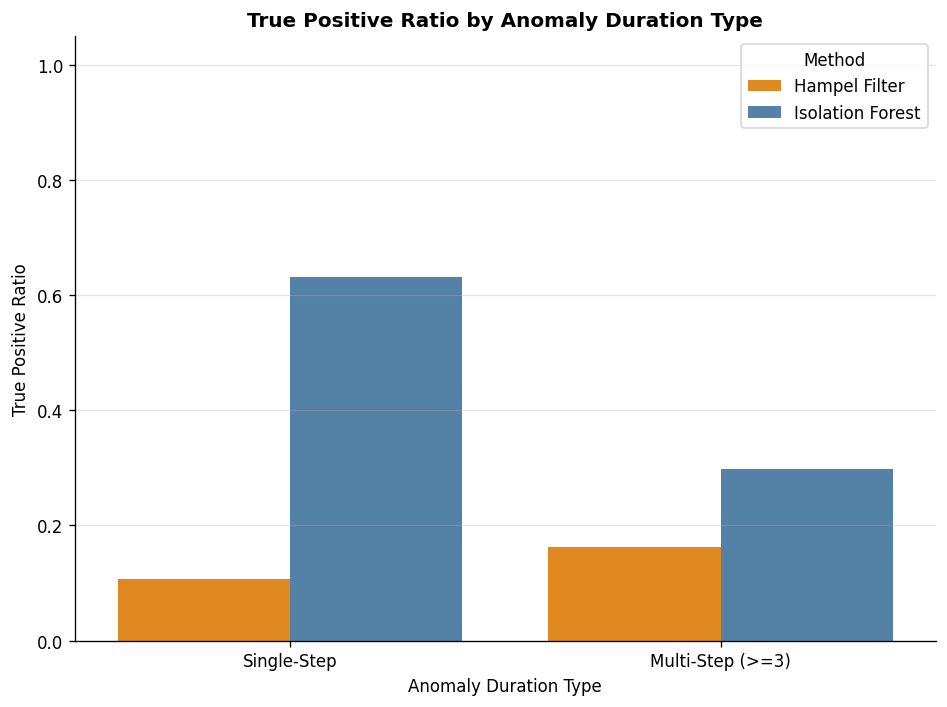

True Positive Ratios by Anomaly Duration:
             Method      Anomaly Type  True Positive Ratio
0     Hampel Filter       Single-Step             0.107143
1     Hampel Filter  Multi-Step (>=3)             0.162562
2  Isolation Forest       Single-Step             0.630952
3  Isolation Forest  Multi-Step (>=3)             0.298522


In [58]:
# Function to classify anomalies by duration
def classify_anomalies_by_duration(y_true_series, min_long_duration=3):
    # Ensure y_true_series is boolean for correct block grouping
    y_true_bool = y_true_series.astype(bool)

    y_true_long_mask = pd.Series(False, index=y_true_series.index)
    y_true_short_mask = pd.Series(False, index=y_true_series.index)

    # Find consecutive blocks of True values
    # This creates a group ID for each contiguous block of True/False values
    anom_blocks = (y_true_bool != y_true_bool.shift()).cumsum()

    # Calculate the length of each block
    block_lengths = y_true_bool.groupby(anom_blocks).transform('sum')

    # Classify based on length for actual anomalies (where y_true_bool is True)
    y_true_long_mask  = y_true_bool & (block_lengths >= min_long_duration)
    y_true_short_mask = y_true_bool & (block_lengths == 1)

    return y_true_short_mask, y_true_long_mask

# Classify anomalies in the ground truth evaluation series
y_true_short, y_true_long = classify_anomalies_by_duration(y_true_eval, min_long_duration=3)

# Calculate True Positives for short anomalies
tp_hampel_short = (y_pred_hamp_[y_true_short] == 1).sum()
tp_if_short     = (y_pred_if_[y_true_short] == 1).sum()
total_short_anomalies = y_true_short.sum()

# Calculate True Positives for long anomalies
tp_hampel_long = (y_pred_hamp_[y_true_long] == 1).sum()
tp_if_long     = (y_pred_if_[y_true_long] == 1).sum()
total_long_anomalies = y_true_long.sum()

# Calculate True Positive Ratios
hampel_short_ratio = tp_hampel_short / total_short_anomalies if total_short_anomalies > 0 else 0
if_short_ratio     = tp_if_short / total_short_anomalies if total_short_anomalies > 0 else 0
hampel_long_ratio  = tp_hampel_long / total_long_anomalies if total_long_anomalies > 0 else 0
if_long_ratio      = tp_if_long / total_long_anomalies if total_long_anomalies > 0 else 0

# Create a DataFrame for plotting
tp_duration_data = pd.DataFrame({
    'Method': ['Hampel Filter', 'Hampel Filter', 'Isolation Forest', 'Isolation Forest'],
    'Anomaly Type': ['Single-Step', 'Multi-Step (>=3)', 'Single-Step', 'Multi-Step (>=3)'],
    'True Positive Ratio': [hampel_short_ratio, hampel_long_ratio, if_short_ratio, if_long_ratio]
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    x='Anomaly Type',
    y='True Positive Ratio',
    hue='Method',
    data=tp_duration_data,
    palette={'Hampel Filter': 'darkorange', 'Isolation Forest': 'steelblue'}
)

ax.set_ylim(0, 1.05)
ax.set_title('True Positive Ratio by Anomaly Duration Type', fontweight='bold')
ax.set_xlabel('Anomaly Duration Type')
ax.set_ylabel('True Positive Ratio')
ax.legend(title='Method')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig('fig_13_tp_duration_comparison.png', bbox_inches='tight')
plt.show()

print("True Positive Ratios by Anomaly Duration:")
print(tp_duration_data)

---
## 7. Summary & Conclusion

In [50]:
winner_f1  = df_results['F1-Score'].idxmax()
winner_roc = df_results['ROC-AUC'].idxmax()
winner_pr  = df_results['PR-AUC'].idxmax()

print("=" * 62)
print("   ANOMALY DETECTION EXPERIMENT - FINAL SUMMARY")
print("=" * 62)
print(f"Dataset     : ESP32 Soil Moisture, 6 sensor nodes")
print(f"Total raw   : {len(df_raw)} records")
print(f"Date range  : {df_raw['recorded_time'].min().date()} -> {df_raw['recorded_time'].max().date()}")
print(f"Eval steps  : {len(y_true_eval)} time-steps (1-min resampled + windowed)")
print(f"Anomaly rate: {y_true_eval.mean()*100:.2f}%")
print()
print("Anomaly Types Injected:")
print(f"  Spike  : delta = {SPIKE_DELTA} (z-score units)")
print(f"  Drop   : delta = {DROP_DELTA} (z-score units)")
print(f"  Drift  : alpha = {DRIFT_ALPHA}, over 20-step window")
print(f"  Stuck  : c = {STUCK_VALUE}, duration = {STUCK_LEN} steps")
print()
print("Best Method by Metric:")
print(f"  F1-Score : {winner_f1}  ({df_results.loc[winner_f1,'F1-Score']:.4f})")
print(f"  ROC-AUC  : {winner_roc} ({df_results.loc[winner_roc,'ROC-AUC']:.4f})")
print(f"  PR-AUC   : {winner_pr}  ({df_results.loc[winner_pr,'PR-AUC']:.4f})")
print()
print("Full Results Table:")
print(df_results.to_string())
print("=" * 62)


   ANOMALY DETECTION EXPERIMENT - FINAL SUMMARY
Dataset     : ESP32 Soil Moisture, 6 sensor nodes
Total raw   : 4206 records
Date range  : 2026-06-25 -> 2026-06-28
Eval steps  : 4642 time-steps (1-min resampled + windowed)
Anomaly rate: 23.89%

Anomaly Types Injected:
  Spike  : delta = 3.5 (z-score units)
  Drop   : delta = 3.5 (z-score units)
  Drift  : alpha = 0.015, over 20-step window
  Stuck  : c = 0.0, duration = 8 steps

Best Method by Metric:
  F1-Score : Isolation Forest  (0.3282)
  ROC-AUC  : Hampel Filter (0.7043)
  PR-AUC   : Hampel Filter  (0.4728)

Full Results Table:
                  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Method                                                        
Hampel Filter        0.7812  0.1578    0.2626   0.7043  0.4728
Isolation Forest     0.3282  0.3282    0.3282   0.5997  0.3161


In [51]:
# Export labeled dataset with all predictions
export_df = df_injected.copy()
export_df['is_anomaly_ground_truth'] = y_true.reindex(export_df.index, fill_value=0)
export_df['hampel_prediction']       = y_pred_hamp.reindex(export_df.index, fill_value=0)
export_df['hampel_score']            = scores_hamp.reindex(export_df.index, fill_value=0)
export_df['if_prediction']           = y_pred_if.reindex(export_df.index, fill_value=0)
export_df['if_score']                = scores_if.reindex(export_df.index, fill_value=0)

export_df.to_csv('soil_moisture_anomaly_labeled.csv')
print("Labeled dataset exported: soil_moisture_anomaly_labeled.csv")
print(f"Shape: {export_df.shape}")
export_df.head()


Labeled dataset exported: soil_moisture_anomaly_labeled.csv
Shape: (4651, 11)


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,is_anomaly_ground_truth,hampel_prediction,hampel_score,if_prediction,if_score
recorded_time,,,,,,,,,,,
2026-06-25 14:30:00,0.600438,-2.340638,1.230159,0.479694,-1.285837,1.876647,0,0,1.124151,0,0.0
2026-06-25 14:31:00,0.715111,-2.323958,1.288113,0.522711,-1.160724,1.913669,0,0,1.011736,0,0.0
2026-06-25 14:32:00,0.829784,-2.307279,1.346068,0.565728,-1.035611,1.950691,0,0,0.899321,0,0.0
2026-06-25 14:33:00,0.944457,-2.290599,1.404022,0.608745,-0.910498,1.987713,0,0,0.674491,0,0.0
2026-06-25 14:34:00,1.059129,-2.273920,1.461976,0.651762,-0.785385,2.024735,0,0,0.505868,0,0.0
